<a href="https://colab.research.google.com/github/TomographicImaging/gVXR-Tutorials/blob/main/notebooks/multi_material-CT_scan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-
#
#  Copyright 2025 United Kingdom Research and Innovation
#  Copyright 2025 Bangor University
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#   Authored by:    Franck Vidal (UKRI-STFC) & Iwan Mitchell (Bangor University)

![gVXR](https://github.com/TomographicImaging/gVXR-Tutorials/blob/main/img/Logo-transparent-small.png?raw=1)

# Single-material example: reproducing the CT scan of a teapot

We acquired the data presented below with the [Dual Tube High Energy (DTHE) device](https://www.rx-solutions.com/en/blog/126/dthe-technology) by [RX Solutions](https://www.rx-solutions.com/) installed at the [MATEIS Laboratory](https://mateis.insa-lyon.fr/en) of [INSA-Lyon](http://www.insa-lyon.fr/). The DTHE is a double tomograph designed around one rotation axis and two 300 kV X-ray beamlines. 
We'll aim to reproduce one of the scans we made. 

![Volume rendering of the CT data](https://github.com/TomographicImaging/gVXR-Tutorials/blob/main/data/Al-part/IMG_3508-smaller.jpg?raw=1)


We'll input all the experimental parameters in the simulation. 
For that purpose, we'll use our JSON format. 
It'll makes it so much easier than typing all the Python code. 
Describe the simulation and there you go.

![Rendering of the simulation](https://github.com/TomographicImaging/gVXR-Tutorials/blob/main/notebooks/output_data/single_material-reproducing_CT_scan/k3d_screenshot-cropped.png?raw=1)


<!-- Up to now, we generated 2D radiographs. 
This time we are going to simulate the computed tomography (CT) acquisition of a section of electric cable. 
A cone-beam geometry is used. 
To keep it simple, we consider an ideal case: no scintillation, no point-spread function (PSF), and a monochromatic spectrum. -->

We will use CIL to reconstruct the CT data with the traditional FDK algorithm.



<div class="alert alert-block alert-warning">
    <b>Note:</b> Make sure the Python packages are already installed. See <a href="../README.md">README.md</a> in the root directory of the repository. If you are running this notebook from Google Colab, please run the cell below to install the required packages.
</div>

## Aims of this session

<!-- 1. Understand the notion of pixel size in the context of a cone-beam geometry and how the magnification affects it.
2. Use OpenSCAD to generate a section of electric cable and save the geometries in STL files.
3. Combine two models made of two different types of material, one chemical element (copper), one a compound (PVC).
4. Simulate an ideal cone-beam computed tomography (CBCT) scan acquisition based on an actual experiment performed with the [Dual Tube High Energy (DTHE) device](https://doi.org/10.1016/j.tmater.2024.100030) by [RX Solutions](https://www.rx-solutions.com/) at [INSA Lyon](https://www.insa-lyon.fr/).
5. Demonstrate how to reconstruct the corresponding CT volume with the [Core Imaging Library (CIL)](https://github.com/TomographicImaging/CIL).
6. Save the reconstructed slices as a TIFF stack using 16-bit unsigned integers.
7. Explore the reconstructed volume and illustrate the partial view artefacts due to the partial view effect on the first and last slices.
8. Use [K3D Jupyter](https://github.com/K3D-tools/K3D-jupyter) to interactively visualise the data with volume rendering.

![Screenshot of the 3D environment using K3D](https://github.com/TomographicImaging/gVXR-Tutorials/blob/main/notebooks/output_data/multi_material-CT_scan/k3d_screenshot-cropped.png?raw=1) -->

## Summary of the ~~simulation~~ experimental parameters

| Parameters | Values | Units | Function call |
|------------|--------|-------|---------------|
| Source to object distance | 400.88 | mm | `gvxr.setSourcePosition(...)` |
| Source type (beam shape) | Point source (cone beam) | | `gvxr.usePointSource()` |
| Tube voltage | 260 | kV |  |
| Tube current | 300 | uA |  |
| Source to detector distance | 858.354 | mm | `gvxr.setDetectorPosition(...)` |
| Detector orientation | [0, 0, 1] |  | `gvxr.setDetectorUpVector(...)` |
| Detector resolution | 2872 &times; 2872 | pixels | `gvxr.setDetectorNumberOfPixels(...)` |
| Pixel pitch | 150 &times; 150 | um | `gvxr.setDetectorPixelSize(...)` |

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !apt-get install libnvidia-gl-575
    !pip install -q condacolab
    import condacolab
    condacolab.install()

    !conda install -y -c conda-forge -c https://software.repos.intel.com/python/conda -c ccpi cil=24.2.0 ipp=2021.12 astra-toolbox=*=cuda* tigre k3d

    !apt-get install -y openscad
    !pip install gvxr viewscad

    import os, urllib.request

    if not os.path.exists("../data/Al-part/Proj"):
        os.makedirs("../data/Al-part/Proj");

    files = ["../data/Al-part/parameters.json",
             "../data/Al-part/IMG_3508.png",
             "../data/Al-part/geom.csv",
             "../data/Al-part/restore.macro",
             "../data/Al-part/unireconstruction.xml",
             "../data/Al-part/Proj/img_00320.tif",
             "notebooks/gvxr2json.py",
             "notebooks/json2gvxr.py",
            ];

    for fname in files:
        url = "https://github.com/TomographicImaging/gVXR-Tutorials/raw/refs/heads/main/" + fname;
        print("Download", url);
        urllib.request.urlretrieve(url, fname);

## Import packages

- `pandas`
- `xml.etree`

<!-- - `os` to create the output directory if needed
- `matplotlib` to show 2D images
- `viewscad` to use OpenSCAD and create STL files
- `base64` to use save a screenshot of the K3D visualisation
- `tifffile.imread` to read the X-ray projection of the real experiment
- `xml.etree.ElementTree` to read the scanning parameters of the real experiment
- `gvxrPython3.gvxr` to simulate X-ray images
- `gvxrPython3.visualise` to use K3D to visualise the 3D environment
- `gvxrPython3.gvxr2json` to save the state of the simulation in JSON file
- `gvxrPython3.JSON2gVXRDataReader` to read the simulated data and prepare it for CIL
- `cil.recon.FDK` to reconstruct the CT volume using the FDK algorithm (3D-CBCT only) 
- `cil.recon.FBP` to reconstruct the CT volume using the FBP algorithm (2D/3D parallel geometry only) 
- `cil.io.TIFFWriter` to save the reconstructed slices as a TIFF stack
- `cil.processors.TransmissionAbsorptionConverter` to normalise the data and apply the minus log
- `cil.utilities.display.show_geometry` to display the acquisition geometry
- `cil.utilities.display.show2D` to show static 2D images
- `cil.utilities.jupyter.islicer` to show and navigate a stack of 2D images using a slider
- `cil.utilities.jupyter.link_islicer` to compare and navigate stacks of 2D images using a slider -->

In [3]:
import os # Create the output directory if necessary
import numpy as np # Who does not use Numpy?

# import math

import matplotlib # To plot images
import matplotlib.pyplot as plt # Plotting
import matplotlib.gridspec as gridspec

font = {'family' : 'serif',
         'size'   : 15
       }
matplotlib.rc('font', **font)

# # Uncomment the line below to use LaTeX fonts
# # matplotlib.rc('text', usetex=True)

# import viewscad # Use OpenSCAD to create STL files

import base64

from tifffile import imread, imwrite

# import xml.etree.ElementTree as ET

from gvxrPython3 import gvxr
from gvxrPython3 import json2gvxr

# import pandas
from xml.etree import ElementTree
from gvxrPython3.utils import has_k3d, visualise

# Use temporary bug fix
if os.path.exists("gvxr2json.py"):
    print("Use temporary bug fix")
    import gvxr2json
#Use the file provided by gVXR's package
else:
    print("Use the file provided by gVXR's package")
    from gvxrPython3 import gvxr2json

# Use temporary bug fix
if os.path.exists("json2gvxr.py"):
    print("Use temporary bug fix")
    import json2gvxr
#Use the file provided by gVXR's package
else:
    print("Use the file provided by gVXR's package")
    from gvxrPython3 import json2gvxr


from tqdm import tqdm


from gvxrPython3.JSON2gVXRDataReader import *

from cil.recon import FDK # For CBCT
# from cil.recon import FBP # For parallel beam geometry

# from cil.io import TIFFWriter

from cil.processors import TransmissionAbsorptionConverter
# from cil.utilities.display import show_geometry, show2D
# from cil.utilities.jupyter import islicer, link_islicer


# from ipywidgets import interact

SimpleGVXR 2.1.0 (2026-05-22T11:04:42) [Compiler: GNU g++] on Linux
gVirtualXRay core library (gvxr) 2.1.0 (2026-05-22T11:04:40) [Compiler: GNU g++] on Linux
Use the file provided by gVXR's package
Use the file provided by gVXR's package


In [4]:
scaling_factor = 4

## Getting the data ready

Where to save the data.m

In [5]:
output_path = "../notebooks/output_data/single_material-reproducing_CT_scan"
if not os.path.exists(output_path):
    os.makedirs(output_path);

## 1. Reading the important information from metadata files

There are three files of interest, one is a spreadsheet; the other two XML files:

- [../data/Al-part/geom.csv](../data/Al-part/geom.csv),
- [../data/Al-part/unireconstruction.xml](../data/Al-part/unireconstruction.xml).
- [../data/Al-part/restore.macro](../data/Al-part/restore.macro).

We'll use Numpy to read the spreadsheet, and xml.etree for the other files. A radiograph is also used to identified the number of pixels in each projection:

[../data/Al-part/Proj/img_00598.tif](../data/Al-part/Proj/img_00320.tif)

In [6]:
# Constant values not available in the metadata
exposures = [0.067, 0.083, 0.111, 0.167, 0.333, 0.500] # [s]
imager_pixel_spacing_in_um = np.array([150, 150])

geom_fname = "../data/Al-part/geom.csv"
unireconstruction_fname = "../data/Al-part/unireconstruction.xml"
restore_fname = "../data/Al-part/restore.macro"
JSON_fname = "../data/Al-part/parameters.json"

1st, the spreadsheet

In [7]:
data = np.loadtxt(geom_fname, 
    delimiter=';',
    skiprows=2,
    usecols=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)
);

new_columns = [
    "source - x",
    "source - y",
    "source - z",
    "Imager Center - x",
    "Imager Center - y",
    "Imager Center - z",
    "Imager Top - x",
    "Imager Top - y",
    "Imager Top - z",
    "Imager Right - x",
    "Imager Right - y",
    "Imager Right - z"
];

# Get the number of projections
N_slices = data.shape[0];

# Get the source position
source_position_set = data[:, [0, 1, 2]]

# Get the detector centre
detector_centre_set = data[:, [3, 4, 5]]

# Get the detector top
detector_top_set = data[:, [6, 7, 8]]

# Get the detector right
detector_right_set = data[:, [9, 10, 11]]

# Compute the rotation angles
angles = np.linspace(0, 360, N_slices, False);

print("Number of projections:", N_slices)


Number of projections: 1120


Convert `detector_top_set` and `detector_right_set` in unit vectors.

In [8]:
for i in range(N_slices):
    detector_top_set[i] -= detector_centre_set[i]
    detector_right_set[i] -= detector_centre_set[i]

    detector_top_set[i] /= np.linalg.norm(detector_top_set[i])
    detector_right_set[i] /= np.linalg.norm(detector_right_set[i])

Plot the data.

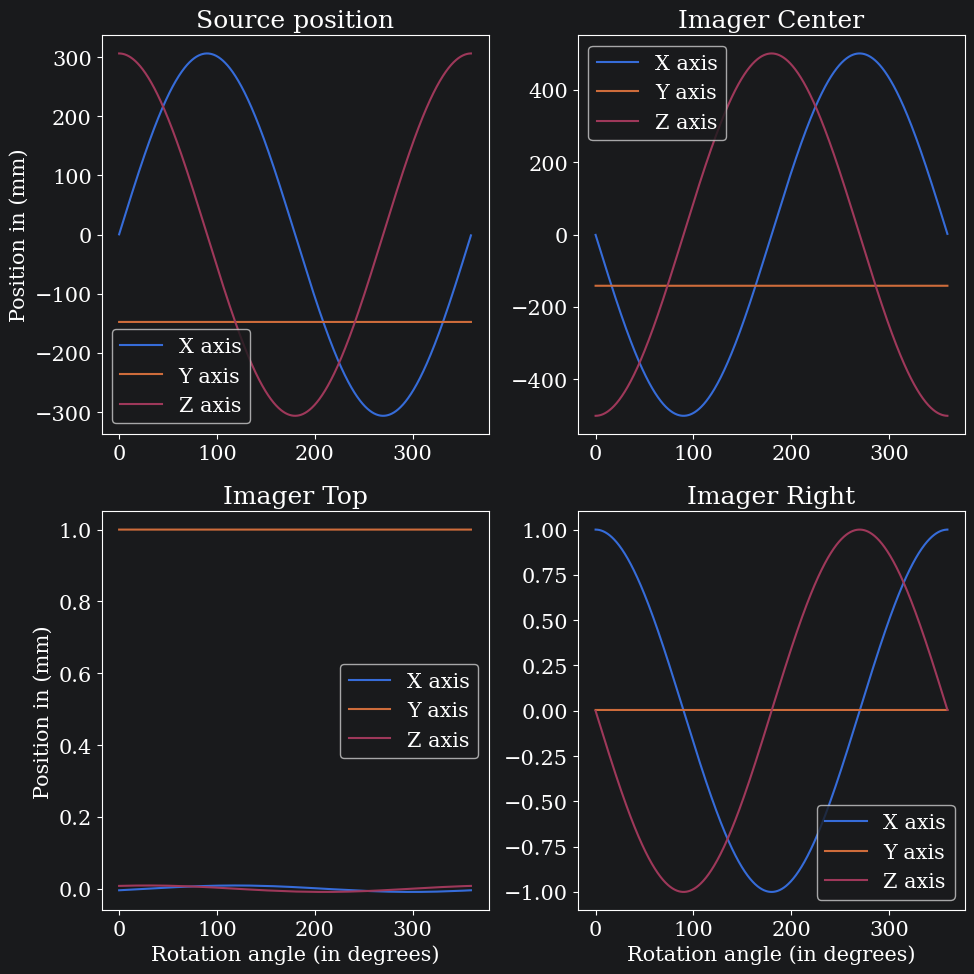

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(10,10));

i = 0; j = 0;
axs[j,i].set_title("Source position");
axs[j,i].plot(angles, source_position_set[:,0], label="X axis");
axs[j,i].plot(angles, source_position_set[:,1], label="Y axis");
axs[j,i].plot(angles, source_position_set[:,2], label="Z axis");
axs[j,i].legend();
# axs[j,i].set_xlabel("Rotation angle (in degrees)");
axs[j,i].set_ylabel("Position in (mm)");

i = 1; j = 0;
axs[j,i].set_title("Imager Center");
axs[j,i].plot(angles, detector_centre_set[:,0], label="X axis");
axs[j,i].plot(angles, detector_centre_set[:,1], label="Y axis");
axs[j,i].plot(angles, detector_centre_set[:,2], label="Z axis");
axs[j,i].legend();
# axs[j,i].set_xlabel("Rotation angle (in degrees)");
# axs[j,i].set_ylabel("Position in (mm)");

i = 0; j = 1;
axs[j,i].set_title("Imager Top");
axs[j,i].plot(angles, detector_top_set[:,0], label="X axis");
axs[j,i].plot(angles, detector_top_set[:,1], label="Y axis");
axs[j,i].plot(angles, detector_top_set[:,2], label="Z axis");
axs[j,i].legend();
axs[j,i].set_xlabel("Rotation angle (in degrees)");
axs[j,i].set_ylabel("Position in (mm)");

i = 1; j = 1;
axs[j,i].set_title("Imager Right");
axs[j,i].plot(angles, detector_right_set[:,0], label="X axis");
axs[j,i].plot(angles, detector_right_set[:,1], label="Y axis");
axs[j,i].plot(angles, detector_right_set[:,2], label="Z axis");
axs[j,i].legend();
axs[j,i].set_xlabel("Rotation angle (in degrees)");
# axs[j,i].set_ylabel("Position in (mm)");

plt.tight_layout()

plt.savefig(output_path + '/trajectories.pdf')
plt.savefig(output_path + '/trajectories.png')

Then the first XML file

In [10]:
# Open the XML file
tree = ElementTree.parse(unireconstruction_fname)

# Find the conebeam profile
profile = tree.find("conebeam/profile")
assert profile is not None

# Get the number of projections
number_of_projections = int(profile.attrib["images"])
assert number_of_projections == N_slices

# Find the acquisition information
acquisition_info = tree.find("conebeam/acquisitioninfo")
assert acquisition_info is not None

# Find the acquisition geometry
conf_geo = acquisition_info.find("geometry")
assert conf_geo is not None

# Get the SDD and SOD
source_to_detector = float(conf_geo.attrib["sdd"])
source_to_object = float(conf_geo.attrib["sod"])
object_to_detector = source_to_detector - source_to_object

print("Profile:", profile)
print("Number of projections:", number_of_projections)

print("Source to detector distance (SDD):", source_to_detector, "mm")
print("Source to object distance (SOD):", source_to_object, "mm")
print("Object to detector distance (ODD):", object_to_detector, "mm")

Profile: <Element 'profile' at 0x7f39cdb200e0>
Number of projections: 1120
Source to detector distance (SDD): 807.249 mm
Source to object distance (SOD): 306.416 mm
Object to detector distance (ODD): 500.833 mm


We also compute the magnification as it will give a sence of the sample size when displaying radiographs.

In [11]:
magnification = source_to_detector / source_to_object;
print("Magnification:", magnification)
spacing_in_mm = (imager_pixel_spacing_in_um / magnification) / 1000.0;

Magnification: 2.634487102501175


We also need details of the X-ray tube.

In [12]:
# Find the acquisition geometry
xray = acquisition_info.find("xray")
assert xray is not None

# Get the SDD and SOD
voltage_in_kV = float(xray.attrib["voltage"])
current_in_uA = float(xray.attrib["current"])

print("Voltage:", voltage_in_kV, "kV")
print("Current:", current_in_uA, "uA")

Voltage: 160.0 kV
Current: 199.0 uA


Now the second XML file. We'll extract or compute:

- Exposure in seconds,
- Exposure in mAs,
- Voltage in kV,
- Current in &mu;A,
- Current in mA, and
- Filtration if any.

In [13]:
# Open the XML file
exposure_ID = None
tree = ElementTree.parse(restore_fname)
root = tree.getroot()
root.tag

# Find the point
point = root[1]
assert point is not None
assert point.tag == "point"

# Find the tube
tube_used = []
for node in point:
    if node.attrib["name"] == "XRay300_1" or node.attrib["name"] == "XRay300_2":

        # Find the exposure
        for tube_property in node:
            if tube_property.attrib["name"] == "voltage":
                voltage_kV = float(tube_property.attrib["value"])
            elif tube_property.attrib["name"] == "current":
                current_uA = float(tube_property.attrib["value"])
                current_mA = current_uA / 1000.0
            elif tube_property.attrib["name"] == "xRayEnabled":
                if tube_property.attrib["value"] == "true":
                    tube_used.append(node.attrib["name"])
            elif tube_property.attrib["name"] == "filter":
                filtration = tube_property.attrib["value"]
                filtration_parameters = filtration.split(" ")
                if len(filtration_parameters) == 3:
                    filtration_parameters[1] = float(filtration_parameters[1])


print("Tube used:", tube_used)

# Find the detector
detector_used = []

# Find the imager that was used
for node in point:
    if node.attrib["name"] == "Imager_" + tube_used[-1][-1]:
        # Find the exposure
        for imager_property in node:
            if imager_property.attrib["name"] == "exposure":
                exposure_ID = int(imager_property.attrib["value"])

assert exposure_ID is not None



exposure_in_s = exposures[exposure_ID - 1]
mAs = exposure_in_s * current_mA
print("Exposure:", exposure_in_s, "s")
print("Exposure:", mAs, "mAs")

print("Voltage", voltage_kV, "kV")
print("Current", current_uA, "uA")
print("Current", current_mA, "mA")
print("Filtration", filtration_parameters)


Tube used: ['XRay300_2']
Exposure: 0.167 s
Exposure: 0.033400000000000006 mAs
Voltage 160.0 kV
Current 200.0 uA
Current 0.2 mA
Filtration ['Cu', 0.4, 'mm']


We can load one of the radiographs.

In [14]:
raw_radiograph_reference = np.array(imread("../data/Al-part/Proj/img_00320.tif"), dtype=np.single)
raw_radiograph_reference /= np.max(raw_radiograph_reference)

and display it either as an attenuation image or absorption image (using the $-\log$ of the attenuation).

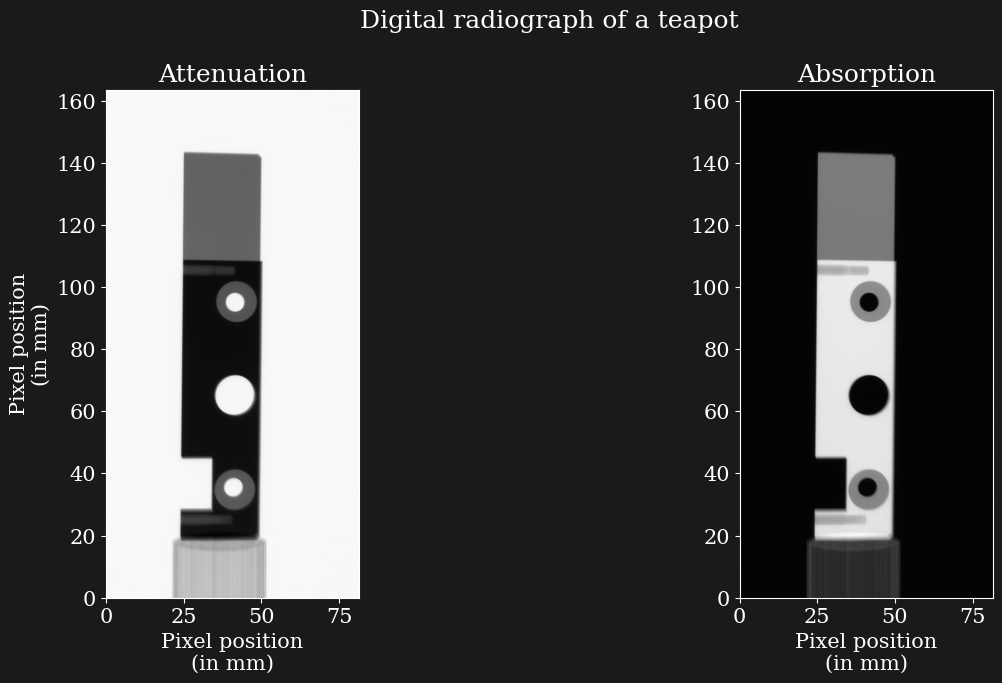

In [15]:
# Plot the two images side-by-side
fig = plt.figure(figsize=(15, 7))
gs = gridspec.GridSpec(1, 2)
axes = [fig.add_subplot(ss) for ss in gs]

extent=[0,(raw_radiograph_reference.shape[1]-1)*spacing_in_mm[0],0,(raw_radiograph_reference.shape[0]-1)*spacing_in_mm[1]]

im1 = axes[0].imshow(raw_radiograph_reference, cmap="gray", extent=extent)
im2 = axes[1].imshow(-np.log(raw_radiograph_reference), cmap="gray", extent=extent)

plt.suptitle("Digital radiograph of a teapot")

axes[0].set_title("Attenuation")
axes[1].set_title("Absorption")

axes[0].set_xlabel("Pixel position\n(in mm)")
axes[1].set_xlabel("Pixel position\n(in mm)")
axes[0].set_ylabel("Pixel position\n(in mm)")

plt.tight_layout()

plt.savefig(output_path + '/reference-radiograph.pdf')
plt.savefig(output_path + '/reference-radiograph.png')

# 2. JSON2gVXR

We will populate a dictionary `params` in the package `gvxrPython3.json2gvxr` to store our experiment/simulation parameters. The dictionary could be automatically populated using a JSON file. I chose this file format as it is more human-friendly than XML.

There is a JSON file in the directory with the data. It is pretty empty for now. It can only initialise the simulation engine and the 3D visualisation environment.

```json
{
    "File format version": [1, 0, 0],
    "Window size": [500, 500]
}
```

Let's load it to initialise the simulation engine.

In [16]:
json2gvxr.initGVXR(JSON_fname)

Create an OpenGL context: 500x500


Tue May 26 11:24:30 2026 ---- Create window (ID: -1)
Tue May 26 11:24:30 2026 ---- Request an interactive OpenGL context
Tue May 26 11:24:30 2026 ---- Initialise GLFW
Tue May 26 11:24:30 2026 ---- Create an OpenGL window with a 3.2 context.
Tue May 26 11:24:30 2026 ---- Make the window's context current
Tue May 26 11:24:30 2026 (WW) GLAD was not initialised as it has been turned off.
Tue May 26 11:24:30 2026 ---- Initialise GLEW
Tue May 26 11:24:30 2026 (EE) ERROR: cannot initialise GLEW:	Missing GL version
Tue May 26 11:24:30 2026 ---- OpenGL vendor: NVIDIA Corporation
Tue May 26 11:24:30 2026 ---- OpenGL renderer: NVIDIA GeForce RTX 4060 Ti/PCIe/SSE2
Tue May 26 11:24:30 2026 ---- OpenGL version: 3.2.0 NVIDIA 580.119.02
Tue May 26 11:24:30 2026 ---- Use OpenGL 4.5.
Tue May 26 11:24:30 2026 ---- Use OpenGL Compute Shader.
Tue May 26 11:24:30 2026 ---- Initialise the X-ray renderer if needed and if possible


Let's start with the detector. The JSON format would be:

```json
{
    "Detector": {
        "Position": [0.0, 0.0, 457.47400000000005, "mm"],
        "UpVector": [0.0, 0.0, -1.0],
        "RightVector": [-1.0, 0.0, 0.0],
        "NumberOfPixels": [2872, 2872],
        "Spacing": [150.0, 150.0, "um"],
        "Scintillator":
        {
            "Material": "Gd2O2S DRZ-Plus",
            "Thickness": 210,
            "Unit": "um"
        }
    }
}
```

Add an empty detector.

In [17]:
json2gvxr.params["Detector"] = {}

Add details about the position, orientation, resolution. An empty scintillation is used for now.

In [18]:
json2gvxr.params["Detector"]["Position"] = [*detector_centre_set[0], "mm"]
json2gvxr.params["Detector"]["UpVector"] = detector_top_set[0]
json2gvxr.params["Detector"]["RightVector"] = detector_right_set[0]
json2gvxr.params["Detector"]["NumberOfPixels"] = [raw_radiograph_reference.shape[1] // scaling_factor, raw_radiograph_reference.shape[0] // scaling_factor]
json2gvxr.params["Detector"]["Spacing"] = [150.0 * scaling_factor, 150.0 * scaling_factor, "um"]
json2gvxr.params["Detector"]["Scintillator"] = {}

Se the scintillator.

In [19]:
json2gvxr.params["Detector"]["Scintillator"]["Material"] = "Gd2O2S DRZ-Plus"
json2gvxr.params["Detector"]["Scintillator"]["Thickness"] = 210
json2gvxr.params["Detector"]["Scintillator"]["Unit"] = "um"


We can now load the detector properties.

In [20]:
json2gvxr.initDetector()

Set up the detector
	Detector position: [-0.753583, -141.345, -500.817, 'mm']
	Detector up vector: [-0.00435672  0.99995977  0.00784123]
	Detector right vector: [ 9.99990170e-01  4.35755656e-03 -8.19369609e-04]
	Number of pixels: [358, 718]
	Detector number of pixels: [358, 718]
	Pixel spacing: [600.0, 600.0, 'um']


Tue May 26 11:24:32 2026 ---- Changed resolution


Display the energy response of the detector corresponding to the scintillator.

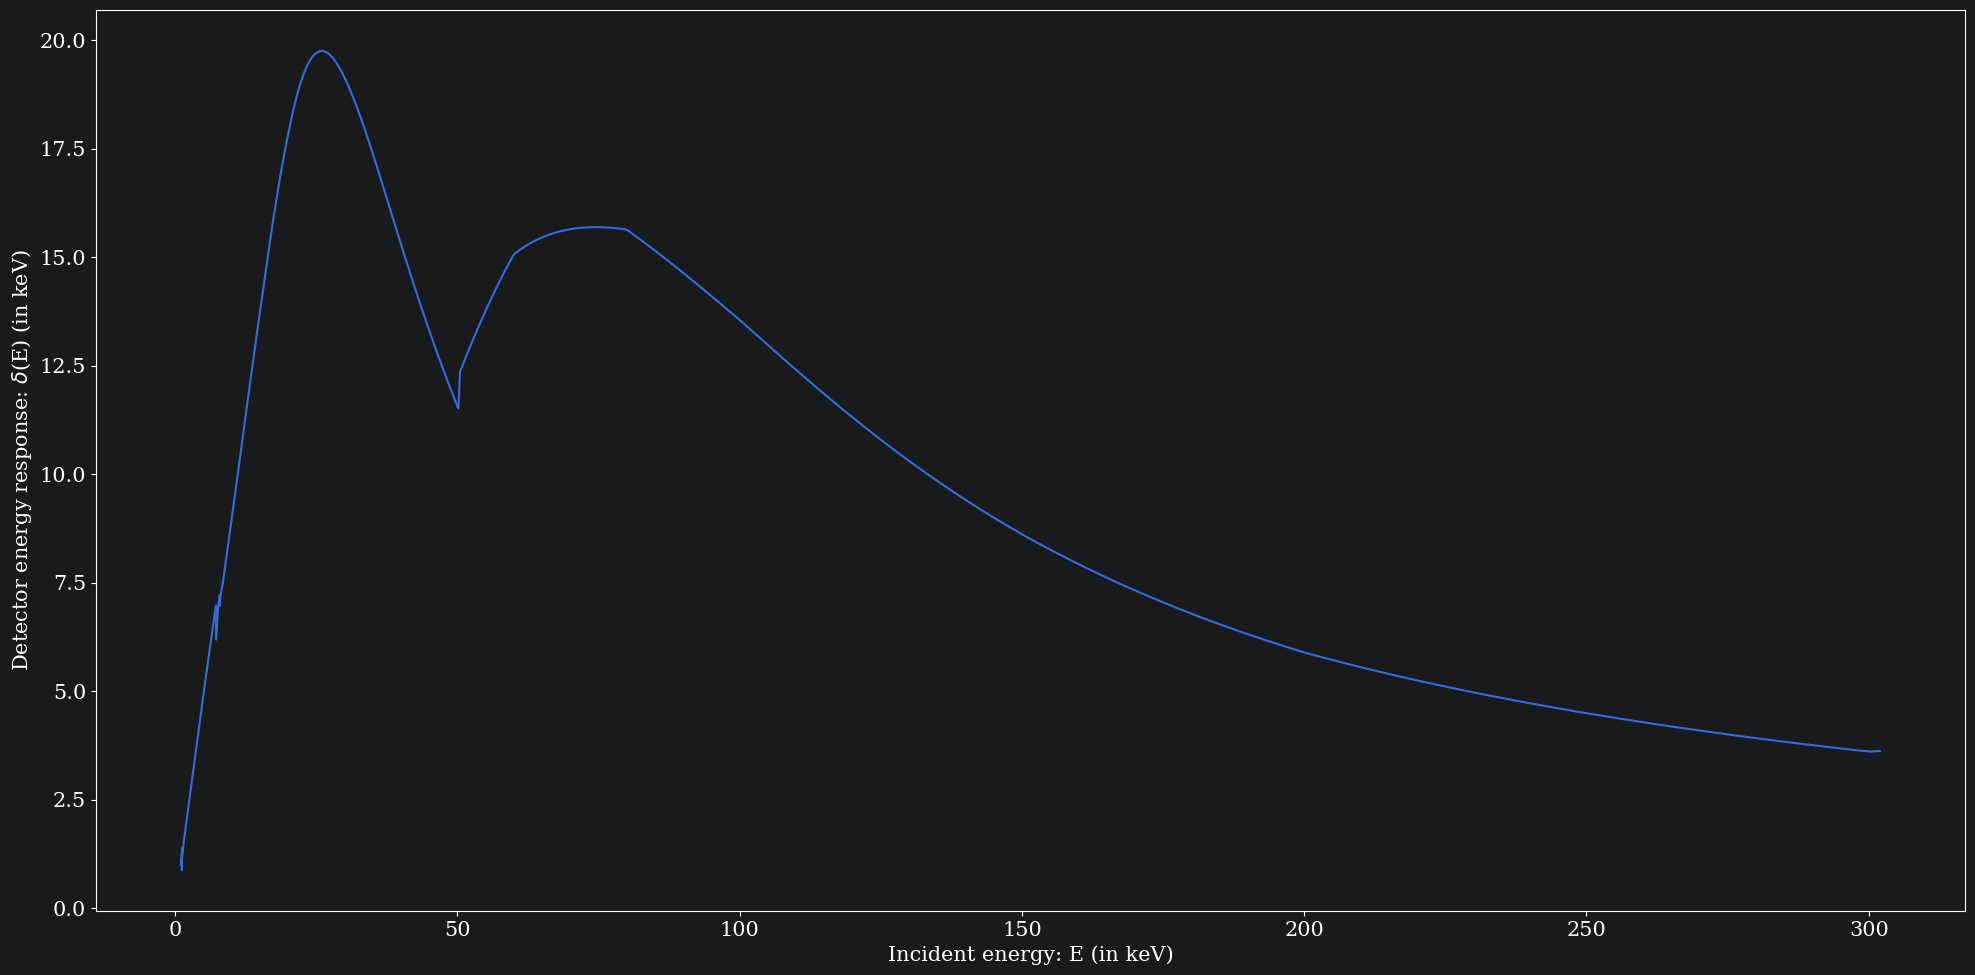

In [21]:
detector_response = np.array(gvxr.getEnergyResponse("keV"));

plt.figure(figsize= (20,10))
# plt.title("Detector response")
plt.plot(detector_response[:,0], detector_response[:,1])
plt.xlabel('Incident energy: E (in keV)')
plt.ylabel('Detector energy response: $\\delta$(E) (in keV)')

plt.tight_layout()

plt.savefig(output_path + '/detector_response.pdf')
plt.savefig(output_path + '/detector_response.png')

We can now worry about the source. The JSON format would be:

```json
{
    "Source": {
        "Position": [0.0, 0, -400.88, "mm"],
        "Shape": "CONEBEAM",
        "Beam": {
            "Peak kilo voltage": 260.0,
            "Tube angle": 12.0,
            "mAs": 0.15,
            "filter": [
                ["Fe", 10.0, "mm"]
            ],
            "maxEnergyBinNumber": 50
        }
    }
}
```

Add an empty source.

In [22]:
json2gvxr.params["Source"] = {}

Add the position and shape of the beam. Also create an empty spectrum.

In [23]:
json2gvxr.params["Source"]["Position"] = [*source_position_set[0], "mm"]
json2gvxr.params["Source"]["Shape"] = "CONEBEAM"
json2gvxr.params["Source"]["Beam"] = {}

Add details about the spectrum.

In [24]:
json2gvxr.params["Source"]["Beam"]["Peak kilo voltage"] = 260.0
json2gvxr.params["Source"]["Beam"]["Tube angle"] = 12.0
json2gvxr.params["Source"]["Beam"]["mAs"]= 0.15
json2gvxr.params["Source"]["Beam"]["filter"] = [
            filtration_parameters
        ]
json2gvxr.params["Source"]["Beam"]["maxEnergyBinNumber"]= 150

We can now load the geometrical source properties.

In [25]:
json2gvxr.initSourceGeometry()

Set up the beam
	Source position: [0.461036, -147.67, 306.406, 'mm']
	Source shape: CONEBEAM


and the spectrum.

In [26]:
spectrum, unit, k, f = json2gvxr.initSpectrum()

Tue May 26 11:24:35 2026 ---- Mixed-precision flag: 255
Tue May 26 11:24:35 2026 ---- Unclean L-buffer precision: 32 bits
Tue May 26 11:24:35 2026 ---- Clean L-buffer precision: 32 bits
Tue May 26 11:24:35 2026 ---- Cumulative L-buffer precision: 32 bits
Tue May 26 11:24:35 2026 ---- Energy fluence precision: 32 bits
Tue May 26 11:24:35 2026 ---- Sum MuX dX precision: 32 bits
Tue May 26 11:24:35 2026 ---- Initialise the renderer with 32 bits per floating-point numbers in GPU memory


s = sp.Spek(kvp= 260.0 , th= 12.0 , mas= 0.15000000596046448 , z= 100
493497161.13486433  photons / cm^2
1776589.8808377478  photons / pixel


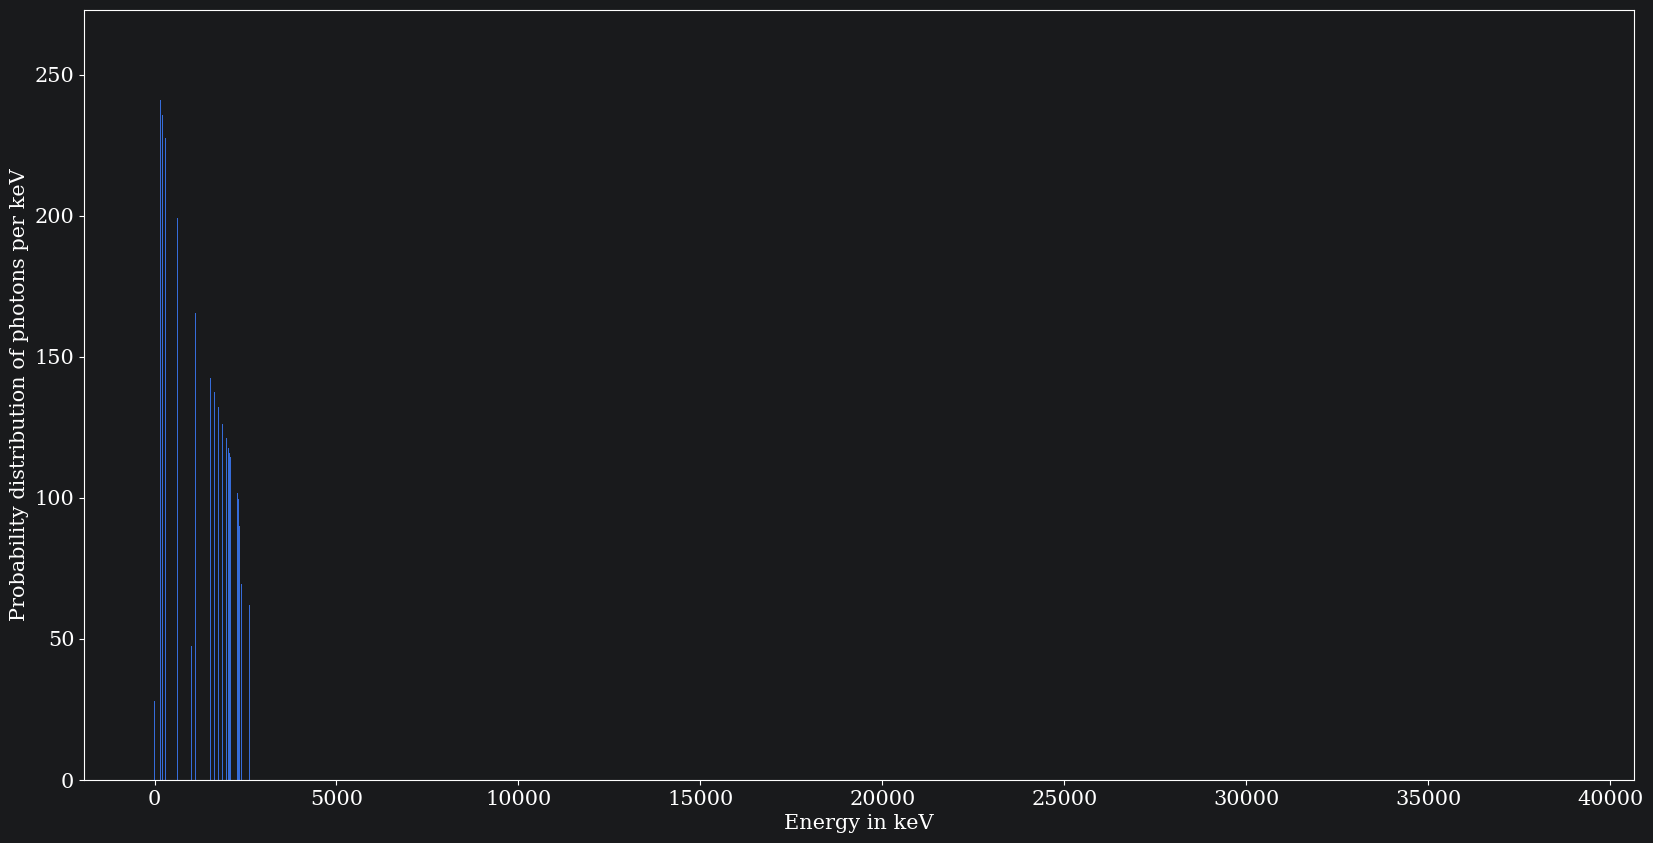

In [27]:
plt.figure(figsize= (20,10))
# plt.title("Beam spectrum")
plt.bar(k, f, width=1)
plt.xlabel('Energy in keV')
plt.ylabel('Probability distribution of photons per keV')
plt.savefig(output_path + "/spectrum.pdf")
plt.show()

We can add our beautiful teapot.

```json
{
    "Samples": [
        {
            "Label": "Teapot",
            "Path": "../data/Al-part/theiere-Fe-10mm/models-teapot.stl",
            "Unit": "mm",
            "Material": ["Mixture", [
                    6, 0.0017,
                    25, 0.014,
                    15, 0.00035,
                    16, 0.00035,
                    29, 0.0055
                    26, 0.9718
                ]
            ],
            "Density": 7.85,
            "AmbientColour": [0.0, 0.0, 0.0, 1.0],
            "DiffuseColour": [0.0, 0.0, 0.0, 1.0],
            "SpecularColour": [0.0, 0.0, 0.0, 1.0],
            "Shininess": 20.0            
        }
    ]
}
```

The `Samples` field corresponds to an array of dictionaries. We add a single one as we only have one teapot. 

In [28]:
json2gvxr.params["Samples"] = [{}]

Then we add our teapot details.

In [29]:
json2gvxr.params["Samples"][0]["Label"] = "MySample"
json2gvxr.params["Samples"][0]["Path"] = "11-Flanc arr.stl"
json2gvxr.params["Samples"][0]["Unit"] = "mm"

The material composition.

In [30]:
json2gvxr.params["Samples"][0]["Material"] = ["Mixture", [
        29, 1.6597528900747764,
        12, 1.4188774576734542,
        25, 0.8741546183982252,
        14, 0.44083027951343545,
        26, 1.924593375949994,
        30, 0.03572670000972014,
        22, 0.037410766726037915,
        24, 0.037331336869174635,
        13, 93.57132257478519
    ]
]
json2gvxr.params["Samples"][0]["Density" ]= 2.542879477629098

We compute the centre of the world then move our mesh there.

In [31]:
source_to_dectector = detector_centre_set[0] - source_position_set[0]
source_to_dectector /= np.linalg.norm(source_to_dectector)

volume_centre_position = source_position_set[0] + source_to_dectector * source_to_object

json2gvxr.params["Samples"][0]["MoveToCenter" ]= True
json2gvxr.params["Samples"][0]["Transform" ]= [
    ["Translation", *volume_centre_position, "mm"],
    ["Rotation", -90, *detector_top_set[0]],
    ["Rotation", -90, *source_to_dectector],
]

We are ready to simulate a radiograph, but hold on, the teapot is matt black! So it must be black and matt in the 3D visualisation too.

In [32]:
RGBA = [208 / 255, 213 / 255, 219 / 255, 1.0]
json2gvxr.params["Samples"][0]["AmbientColour"] = RGBA
json2gvxr.params["Samples"][0]["DiffuseColour"] = RGBA
json2gvxr.params["Samples"][0]["SpecularColour"] = RGBA
json2gvxr.params["Samples"][0]["Shininess"] = 200.0            

We load the sample.

In [33]:
json2gvxr.initSamples()

Tue May 26 11:24:39 2026 ---- file_name:	/home/fpvidal/PROGRAMMING/GitHub/gVXR-Tutorials/data/Al-part/11-Flanc arr.stl	nb_faces:	3932	nb_vertices:	11796	bounding_box (in cm):	(-7.8, -0.5, -0.8)	(4.6, 0.5, 1.7)


We are now ready to compute an X-ray image and display it.

In [34]:
gvxr.disablePoissonNoise()
x_ray_image = np.array(gvxr.computeXRayImage(), dtype=np.single) / gvxr.getTotalEnergyWithDetectorResponse();
# gvxr.displayScene()


We can display it side-by-side with the experimental image.

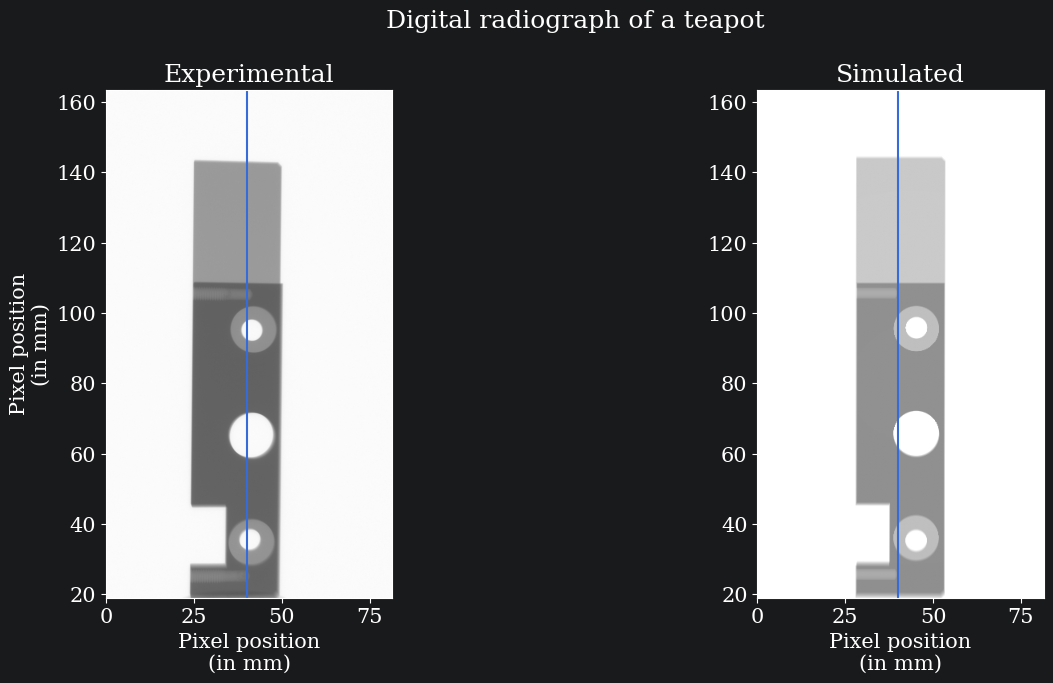

In [35]:
# Plot the two images side-by-side
fig = plt.figure(figsize=(15, 7))
gs = gridspec.GridSpec(1, 2)
axes = [fig.add_subplot(ss) for ss in gs]

extent=[0,(raw_radiograph_reference.shape[1]-1)*spacing_in_mm[0],0,(raw_radiograph_reference.shape[0]-1)*spacing_in_mm[1]]

im1 = axes[0].imshow(raw_radiograph_reference, cmap="gray", extent=extent, vmin=0, vmax=1)
im2 = axes[1].imshow(x_ray_image, cmap="gray", extent=extent, vmin=0, vmax=1)

axes[0].plot([extent[1] // 2, extent[1] // 2], [0, extent[3]])
axes[1].plot([extent[1] // 2, extent[1] // 2], [0, extent[3]])

plt.suptitle("Digital radiograph of a teapot")

axes[0].set_title("Experimental")
axes[1].set_title("Simulated")

axes[0].set_xlabel("Pixel position\n(in mm)")
axes[1].set_xlabel("Pixel position\n(in mm)")
axes[0].set_ylabel("Pixel position\n(in mm)")

axes[0].set_ylim(19, extent[3])
axes[1].set_ylim(19, extent[3])

plt.tight_layout()

plt.savefig(output_path + '/difference-radiograph.pdf')
plt.savefig(output_path + '/difference-radiograph.png')

It may be useful to visualise the 3D environment to ascertain everything is as expected. We use k3D if possible. It's a nice 3D visualisation framework for Jupyter notebooks.

In [36]:
if IN_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()

plot = visualise(use_log=True, use_negative=True, sharpen_ksize=2, sharpen_alpha=1.0);

if plot:
    plot.display();

Output()

In [37]:
if plot:
    plot.fetch_screenshot();

In [38]:
if plot:
    screenshot_fname = os.path.join(output_path, "k3d_screenshot.png");
    if not os.path.exists(screenshot_fname):
        k3d_screenshot = plot.screenshot;
        data = base64.b64decode(k3d_screenshot);
        with open(screenshot_fname, "wb") as fp:
            fp.write(data);
            fp.flush();
            fp.close();

if IN_COLAB:
    output.disable_custom_widget_manager()

## 4. Compute the X-ray projections for a CT acquisition

In [39]:
proj_path = os.path.join(output_path, "simulated_projections")

if not os.path.exists(proj_path):
     os.mkdir(proj_path);
        
total_incident_energy = gvxr.getTotalEnergyWithDetectorResponse()

with tqdm(total=number_of_projections) as pbar:

     for i, (source_position, detector_position, detector_direction_x, detector_direction_y) in enumerate(zip(source_position_set, detector_centre_set, detector_right_set, detector_top_set)):

          gvxr.setSourcePosition(source_position[0], source_position[1], source_position[2], "mm");

          gvxr.autoAlignDetector(False);
          gvxr.setDetectorPosition(detector_position[0], detector_position[1], detector_position[2], "mm");
          gvxr.setDetectorUpVector(detector_direction_y[0], detector_direction_y[1], detector_direction_y[2]);
          gvxr.setDetectorRightVector(detector_direction_x[0], detector_direction_x[1], detector_direction_x[2]);

          # Compute an X-ray image
          # We convert the array in a Numpy structure and store the data using single-precision floating-point numbers.
          xray_image = np.array(gvxr.computeXRayImage(), dtype=np.single) / total_incident_energy
          imwrite(os.path.join(proj_path, "img_" + str(i).zfill(5) + ".tif"), xray_image, compression ="zlib");

          pbar.update()

100%|██████████| 1120/1120 [13:02<00:00,  1.43it/s]


In [40]:
# Save the current simulation states in a JSON file.
# It could be used to re-run the simulation, or to read the data with CIL.
json_fname = os.path.join(output_path, "simulation-" + str(number_of_projections) + ".json");
gvxr2json.saveJSON(json_fname);

mAs -1.0 kVp -1000.0


Tue May 26 11:37:51 2026 (WW) getPhotonCountEnergyBins is deprecated. It will be removed in a future release. Choose getPhotonCountsPerPixelAtSDD or getPhotonCountsPerCm2At1m. Note that getEnergyChannel and getPhotonCountsPerPixelAtSDD are equivalent.


## 5. Demonstrate how to reconstruct the corresponding CT volume with the [Core Imaging Library (CIL)](https://github.com/TomographicImaging/CIL).

In [41]:
# Read the simulated data with CIL.
reader = JSON2gVXRDataReader(json_fname);
data = reader.read()

KeyError: 'Scan'

In [ ]:
print("data.geometry", data.geometry)

In [ ]:
show2D(data)

In [ ]:
islicer(data)

In [ ]:
data_corr = TransmissionAbsorptionConverter(white_level=data.max())(data)

In [ ]:
show2D(data_corr)

In [ ]:
islicer(data_corr)

In [ ]:
data_corr.reorder(order='tigre')

In [ ]:
ig = data_corr.geometry.get_ImageGeometry();

print("Image geometry", ig)

In [ ]:
# Perform the reconstruction with CIL
FDK_reconstruction = FDK(data_corr, ig).run()

In [ ]:
# Look at partial view artefacts
show2D(FDK_reconstruction, slice_list=[1, FDK_reconstruction.shape[0] // 2, FDK_reconstruction.shape[0] - 2], title=["2nd slice", "Middle slice", "Slice before last"], num_cols=3)

## 6. Save the reconstructed slices as a TIFF stack using 16-bit unsigned integers.


In [ ]:
# Save the reconstructed CT images
writer = TIFFWriter(data=FDK_reconstruction, file_name=os.path.join(output_path, "recons-" + str(number_of_projections), "slice_"), compression="uint16");
writer.write();

## 7. Explore the reconstructed volume and illustrate the partial view artefacts due to the partial view effect on the first and last slices.

In [ ]:
islicer(FDK_reconstruction, minmax=None)

## 8. Volume rendering with [K3D Jupyter](https://github.com/K3D-tools/K3D-jupyter)

First, we compute the volume bound to make sure the voxel size is taken into account. This is particularly important if the voxel size is not isotropic.

In [ ]:
bounds = [
    ig.center_x - ig.voxel_num_x / 2.0 * ig.voxel_size_x,
    ig.center_x + ig.voxel_num_x / 2.0 * ig.voxel_size_x,

    ig.center_y - ig.voxel_num_y / 2.0 * ig.voxel_size_y,
    ig.center_y + ig.voxel_num_y / 2.0 * ig.voxel_size_y,

    ig.center_z - ig.voxel_num_z / 2.0 * ig.voxel_size_z,
    ig.center_z + ig.voxel_num_z / 2.0 * ig.voxel_size_z
]

We retrieve the Numpy array from the CIL volume, and create a k3D volume.

In [ ]:
if has_k3d:
    CT_volume = k3d.volume(FDK_reconstruction.as_array().astype(np.single), 
                        color_map=np.array(k3d.basic_color_maps.Jet, dtype=np.float32),
                        bounds=bounds, 
    )

Visualise the CT data using volume rendering.

---
## Task:

- Run the cell below,
- In the control panel on the right-hand side, adjust the values in the tab `Objects->Volume #1`.

In [ ]:
if has_k3d:
    if IN_COLAB:
        from google.colab import output
        output.enable_custom_widget_manager()

    plot = k3d.plot()
    plot += CT_volume
    plot.display()

It is possible to control the visualisation from the code directly.

---
## Task:

- Run the cell below,
- Adjust the sliders:
    - to show air with transparency, and
    - to reveal the electric cable.

In [ ]:
if has_k3d:
    min_value = FDK_reconstruction.min()
    max_value = FDK_reconstruction.max()

    def update(vmin=min_value, vmax=max_value):
        CT_volume.color_range = [min(vmin, vmax), max(vmin, vmax)]

    interact(update, vmin=(min_value, max_value), vmax=(min_value, max_value));

# Further work

We can clearly see streak artefacts in the reconstructed volume. This is because the number of projections is too low. It is called "Aliasing Artefacts" in the occurence. You can read about it in [Chapter 5 on "Aliasing Artifacts and Noise in CT Images"](https://doi.org/10.1137/1.9780898719277.ch5) of the famous book entitled ["Principles of Computerized Tomographic Imaging"](https://doi.org/10.1137/1.9780898719277) by Avinash C. Kak and Malcolm Slaney. See https://engineering.purdue.edu/~malcolm/pct/ for details.

As a rule of thumb, the number of projections should be at least:
$$
\frac{\pi}{2} \times ncols
$$

with $ncols$ the number of pixels of the detector along the x-axis. In our case, it is equal to `gxvr.getDetectorNumberOfPixels()[0]`

---
## Task:

- Identify the size of the detector using `gxvr.getDetectorNumberOfPixels()[0]` in the cell below,
- Use the formula provided above to calculate the number of projections we should have used in theory,
- Compare this value with 200, the default number of projections we use in this notebook, it was far too low indeed,
- Increase the number of projections in the call of `gvxr.computeCTAcquisition(...)`, and
- Re-run the notebook.

In [ ]:
0.6000000238418579

# Cleaning up

Once we have finished, it is good practice to clean up the OpenGL contexts and windows with the following command. Note that due to the object-oriented programming nature of the core API of gVXR, this step is automatic anyway.

In [ ]:
gvxr.destroy();